<a href="https://colab.research.google.com/github/princevp2006-source/synent-task3-ExploratoryDataAnalysis-prince/blob/main/Basic_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("netflix_titles.csv")

In [2]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.shape

(8807, 12)

In [5]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [6]:
print(df.describe())

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [7]:
print(print(df.describe(include='object')))

       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  Movie  Zubaan  Rajiv Chilaka  David Attenborough   
freq         1   6131       1             19                  19   

              country       date_added rating  duration  \
count            7976             8797   8803      8804   
unique            748             1767     17       220   
top     United States  January 1, 2020  TV-MA  1 Season   
freq             2818              109   3207      1793   

                           listed_in  \
count                           8807   
unique                           514   
top     Dramas, International Movies   
freq                             362   

                                              description  
count                                                8807  
unique                                    

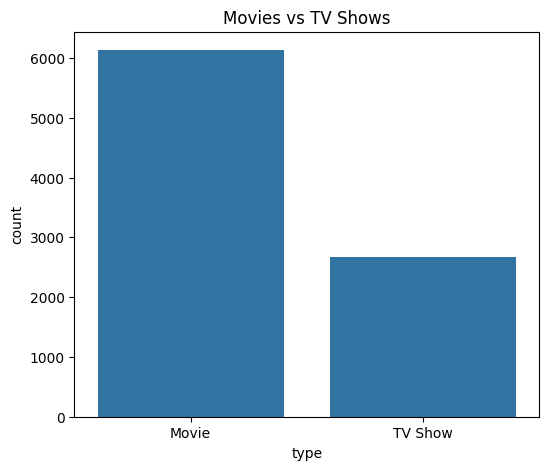

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows")

plt.show()

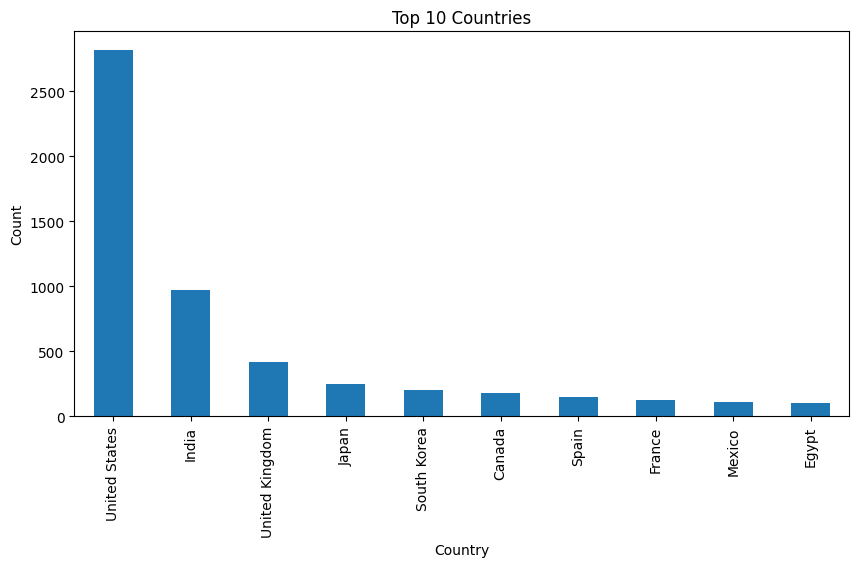

In [9]:
# --------------------------------
# Graph 2: Top 10 Countries
# --------------------------------

top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_country.plot(kind='bar')

plt.title("Top 10 Countries")

plt.xlabel("Country")

plt.ylabel("Count")

plt.show()

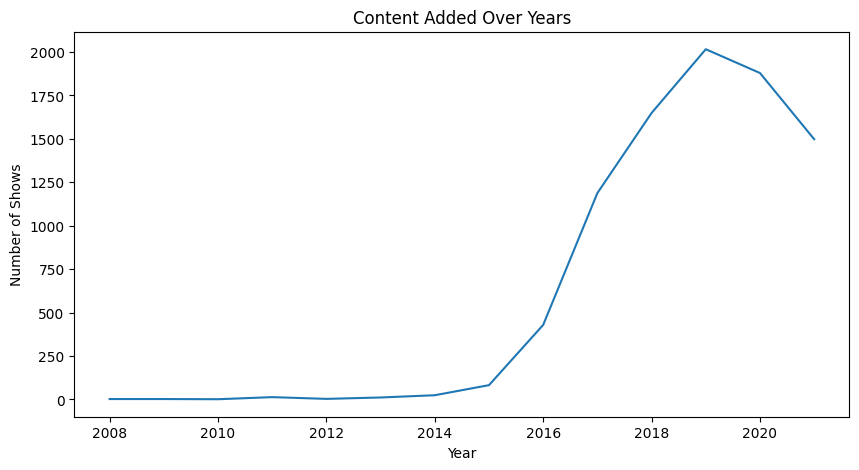

In [11]:
# --------------------------------
# Graph 3: Content Added Over Years
# --------------------------------

# Convert date column
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

# Extract year
df['year_added'] = df['date_added'].dt.year

plt.figure(figsize=(10,5))

df['year_added'].value_counts().sort_index().plot()

plt.title("Content Added Over Years")

plt.xlabel("Year")

plt.ylabel("Number of Shows")

plt.show()

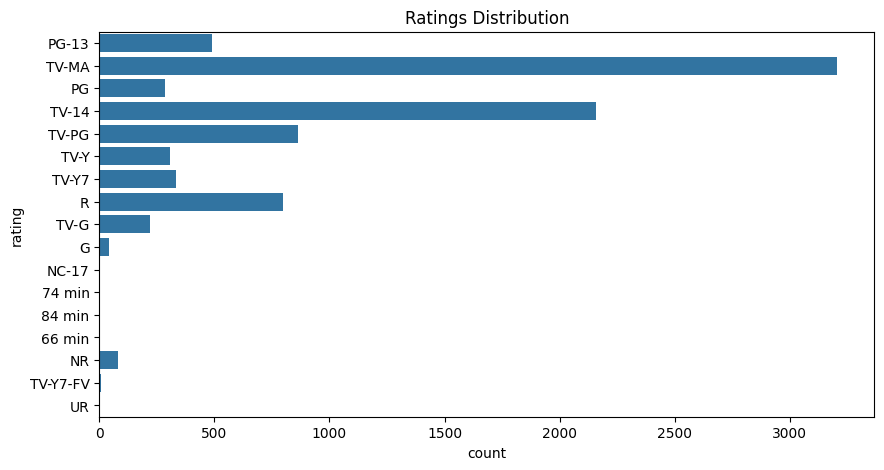

In [12]:
# --------------------------------
# Graph 4: Ratings Distribution
# --------------------------------

plt.figure(figsize=(10,5))

sns.countplot(y='rating', data=df)

plt.title("Ratings Distribution")

plt.show()


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_7854/2331956958.py:9: SyntaxWarning: invalid escape sequence '\d'
  movie_df['duration_int'] = movie_df['duration'].str.extract('(\d+)')


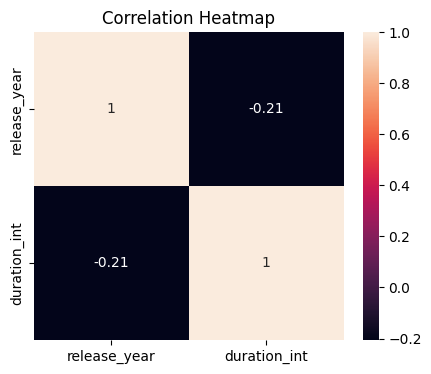

In [15]:
# --------------------------------
# Correlation Heatmap
# --------------------------------

# Select Movies Only
movie_df = df[df['type'] == 'Movie'].copy()

# Extract duration number
movie_df['duration_int'] = movie_df['duration'].str.extract('(\d+)')

# Convert into numeric
movie_df['duration_int'] = pd.to_numeric(movie_df['duration_int'])

# Correlation
corr = movie_df[['release_year', 'duration_int']].corr()

plt.figure(figsize=(5,4))

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()


In [16]:
# --------------------------------
# Insights
# --------------------------------

print("Netflix has more Movies than TV Shows")

print("United States has most content")

print("Content increased after 2015")

print("TV-MA is common rating")

Netflix has more Movies than TV Shows
United States has most content
Content increased after 2015
TV-MA is common rating
